# 金融对话数值推理模型：SFT → 轻量 DPO / GRPO → benchmark 评估

目标：训练一个面向 **金融对话数值推理** 的 reasoning model。

整体闭环：
- **SFT-1（FinQA）**：先学习表文混合数值推理与程序监督
- **SFT-2（ConvFinQA）**：再学习多轮对话中的 follow-up 数值推理
- **DPO（可选）**：小规模优化表达质量、结构和少废话
- **GRPO（推荐）**：基于可验证 reward 优化答案正确性、程序一致性与结构约束
- **benchmark 评估**：`FinQA / ConvFinQA + CFLUE + FinanceBench + AdaptLLM/finance-tasks`

本 Notebook 复用 MedicalGPT 的训练框架：
- 数据格式遵循 `docs/datasets.md`
- pipeline 参考 `run_training_dpo_pipeline.ipynb`


## 0. 环境准备（可选）

如果你在全新环境运行，请先安装依赖；已按项目 README 配好可跳过。


In [2]:
!pip install -r requirements.txt --upgrade

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 38.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 32.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.7 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.7 MB/s  0:00:00m eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 10.3 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 14.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 13.0 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 10.4 MB/s  0:00:01 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 58.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.6/530.6 MB 9.6 MB/s  0:00:540:00:0100:02
     ━━━━━━━

In [1]:
!pip install modelscope


Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 10.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [modelscope]8 [modelscope]


In [6]:
# HF Mirror（可选）
import os
HF_ENDPOINT = "https://hf-mirror.com"
os.environ["HF_ENDPOINT"] = HF_ENDPOINT
print("HF_ENDPOINT:", os.getenv("HF_ENDPOINT"))


HF_ENDPOINT: https://hf-mirror.com


## 1. 任务配置

这里把配置拆成五部分：
1. 阶段一数据 `SFT-1 (FinQA)`
2. 阶段二数据 `SFT-2 (ConvFinQA)`
3. 原始数据下载缓存目录
4. 转换 / 清洗 / 混合目录
5. 训练与评估输出目录


In [8]:
from pathlib import Path
import json
import random
from itertools import islice

BASE_MODEL = "/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct"

TEMPLATE_NAME = "qwen"
RANDOM_SEED = 42
FORCE_REDOWNLOAD_RAW = False

# ==== 根路径统一配置（数据盘） ====
DISK_ROOT = Path("/root/autodl-tmp")
OUT_DIR = DISK_ROOT / "data" / "financial_reasoning"
OUTPUT_ROOT = DISK_ROOT / "outputs" / "financial_reasoning"

RAW_CACHE_DIR = OUT_DIR / "raw"
SFT1_SFT_DIR = OUT_DIR / "sft1_sharegpt"
SFT2_SFT_DIR = OUT_DIR / "sft2_sharegpt"
DPO_DIR = OUT_DIR / "dpo_pairs"
MIXED_DIR = OUT_DIR / "mixed"
CLEAN_DIR = OUT_DIR / "clean"
REPORT_DIR = OUT_DIR / "reports"

SFT1_MIXED_FILE = MIXED_DIR / "train_sft1_mixed.jsonl"
SFT2_MIXED_FILE = MIXED_DIR / "train_sft2_mixed.jsonl"
DPO_MIXED_FILE = DPO_DIR / "train_reasoning_dpo.jsonl"
SFT1_CLEAN_FILE = CLEAN_DIR / "train_sft1_clean.jsonl"
SFT2_CLEAN_FILE = CLEAN_DIR / "train_sft2_clean.jsonl"

SFT1_DIR = CLEAN_DIR / "sft1_dir_strict"
SFT2_DIR = CLEAN_DIR / "sft2_dir_strict"
DPO_TRAIN_DIR = DPO_DIR / "train_dir"

SFT1_AUDIT_DIR = CLEAN_DIR / "audit_sft1"
SFT2_AUDIT_DIR = CLEAN_DIR / "audit_sft2"
SFT1_STRICT_FILE = CLEAN_DIR / "train_sft1_clean_strict.jsonl"
SFT2_STRICT_FILE = CLEAN_DIR / "train_sft2_clean_strict.jsonl"

# 训练/日志输出改到数据盘
SFT1_OUT = OUTPUT_ROOT / "sft1_lora"
SFT1_MERGED_OUT = OUTPUT_ROOT / "sft1_merged"
SFT2_OUT = OUTPUT_ROOT / "sft2_lora"
SFT2_MERGED_OUT = OUTPUT_ROOT / "sft2_merged"
DPO_OUT = OUTPUT_ROOT / "dpo_lora"
DPO_MERGED_OUT = OUTPUT_ROOT / "dpo_merged"
TB_LOG_DIR = OUTPUT_ROOT / "tensorboard"

for d in [
    RAW_CACHE_DIR, SFT1_SFT_DIR, SFT2_SFT_DIR, DPO_DIR, MIXED_DIR, CLEAN_DIR, REPORT_DIR,
    SFT1_DIR, SFT2_DIR, DPO_TRAIN_DIR, SFT1_AUDIT_DIR, SFT2_AUDIT_DIR, OUTPUT_ROOT, TB_LOG_DIR,
    SFT1_OUT, SFT1_MERGED_OUT, SFT2_OUT, SFT2_MERGED_OUT, DPO_OUT, DPO_MERGED_OUT,
]:
    d.mkdir(parents=True, exist_ok=True)

SFT1_TOTAL_BUDGET = 6251
SFT2_EXTRA_BUDGET = 7059
DPO_TOTAL_BUDGET = 4000
MAX_DPO_PER_DATASET = 2000

SFT1_DATA_SPECS = [
    {
        "name": "finqa_train",
        "family": "finqa",
        "source_type": "local",
        "local_path": RAW_CACHE_DIR / "finqa" / "train.json",
        "split": "train",
        "weight": 1.0,
        "max_rows": 6251,
        "description": "阶段一：表格 + 文本 + 程序推理（FinQA）",
    },
]

SFT2_DATA_SPECS = [
    {
        "name": "fingpt_convfinqa_train",
        "family": "convfinqa_turn",
        "source_type": "local",
        "local_path": RAW_CACHE_DIR / "convfinqa_turn" / "train_turn.json",
        "split": "train",
        "weight": 1.0,
        "max_rows": None,
        "description": "阶段二：多轮金融对话 + 数值推理（ConvFinQA）",
    },
]

BENCHMARK_SPECS = [
    {"name": "ConvFinQA_dev", "role": "核心多轮数值推理"},
    {"name": "FinQA_dev", "role": "核心表文混合推理"},
    {"name": "CFLUE", "role": "中文金融泛化"},
    {"name": "FinanceBench", "role": "开放书金融 QA 迁移"},
    {"name": "AdaptLLM/finance-tasks", "role": "补充 benchmark"},
]


def allocate_target_rows(specs, total_budget: int, default_cap: int | None = None):
    if not specs:
        return []
    total_weight = sum(max(float(spec.get("weight", 0.0)), 0.0) for spec in specs)
    if total_weight <= 0:
        raise ValueError("All dataset weights are zero; cannot allocate target_rows.")

    allocated = []
    for spec in specs:
        raw_target = int(round(total_budget * float(spec.get("weight", 0.0)) / total_weight))
        cap = spec.get("max_rows", default_cap)
        if cap is not None:
            raw_target = min(raw_target, int(cap))
        spec = dict(spec)
        spec["target_rows"] = max(raw_target, 0)
        allocated.append(spec)
    return allocated


SFT1_DATA_SPECS = allocate_target_rows(SFT1_DATA_SPECS, SFT1_TOTAL_BUDGET)
SFT2_DATA_SPECS = allocate_target_rows(SFT2_DATA_SPECS, SFT2_EXTRA_BUDGET)

print("DISK_ROOT:", DISK_ROOT)
print("OUT_DIR:", OUT_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("BASE_MODEL:", BASE_MODEL)
print("SFT1_TOTAL_BUDGET:", SFT1_TOTAL_BUDGET)
print("SFT2_EXTRA_BUDGET:", SFT2_EXTRA_BUDGET)
print("DPO_TOTAL_BUDGET:", DPO_TOTAL_BUDGET)
print("SFT1_DATA_SPECS:", json.dumps([{**spec, 'local_path': str(spec.get('local_path', ''))} for spec in SFT1_DATA_SPECS], ensure_ascii=False, indent=2))
print("SFT2_DATA_SPECS:", json.dumps([{**spec, 'local_path': str(spec.get('local_path', ''))} for spec in SFT2_DATA_SPECS], ensure_ascii=False, indent=2))
print("BENCHMARK_SPECS:", json.dumps(BENCHMARK_SPECS, ensure_ascii=False, indent=2))


DISK_ROOT: /root/autodl-tmp
OUT_DIR: /root/autodl-tmp/data/financial_reasoning
OUTPUT_ROOT: /root/autodl-tmp/outputs/financial_reasoning
BASE_MODEL: /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct
SFT1_TOTAL_BUDGET: 6251
SFT2_EXTRA_BUDGET: 7059
DPO_TOTAL_BUDGET: 4000
SFT1_DATA_SPECS: [
  {
    "name": "finqa_train",
    "family": "finqa",
    "source_type": "local",
    "local_path": "/root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json",
    "split": "train",
    "weight": 1.0,
    "max_rows": 6251,
    "description": "阶段一：表格 + 文本 + 程序推理（FinQA）",
    "target_rows": 6251
  }
]
SFT2_DATA_SPECS: [
  {
    "name": "fingpt_convfinqa_train",
    "family": "convfinqa_turn",
    "source_type": "local",
    "local_path": "/root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json",
    "split": "train",
    "weight": 1.0,
    "max_rows": null,
    "description": "阶段二：多轮金融对话 + 数值推理（ConvFinQA）",
    "target_rows": 7059
  }
]
BENCHMARK_SPECS: [
  {
    "name": "Conv

## 1.1 统一任务格式

本次两阶段 SFT 的主训练模板：
- **ConvFinQA**：历史对话 + 当前问题 + 表格/文本上下文 → 分步推理 → 最终答案
- **FinQA**：文本 + 表格 + 问题 → reasoning program / 中间步骤 → 执行结果

MedicalGPT 对数据格式的要求：
- **SFT**：`conversations`
- **DPO**：`question + response_chosen + response_rejected`

> 注：路由器仍支持 `fineval/fiqa_qa` family，但当前 notebook 的 SFT 两阶段不使用它们。


In [16]:
from pprint import pprint

SFT_SCHEMA_EXAMPLE = {
    "conversations": [
        {"from": "human", "value": "历史对话 + 当前问题 + 文本/表格上下文"},
        {"from": "gpt", "value": "问题分析...\n关键证据...\n推理程序...\n最终答案..."},
    ]
}

DPO_SCHEMA_EXAMPLE = {
    "system": "",
    "history": [],
    "question": "统一格式的金融推理问题",
    "response_chosen": "结构化且正确的回答",
    "response_rejected": "答案错误或程序不一致的回答",
}

print("[MedicalGPT SFT schema]")
pprint(SFT_SCHEMA_EXAMPLE, sort_dicts=False)
print("[MedicalGPT DPO schema]")
pprint(DPO_SCHEMA_EXAMPLE, sort_dicts=False)


[MedicalGPT SFT schema]
{'conversations': [{'from': 'human', 'value': '历史对话 + 当前问题 + 文本/表格上下文'},
                   {'from': 'gpt',
                    'value': '问题分析...\n关键证据...\n推理程序...\n最终答案...'}]}
[MedicalGPT DPO schema]
{'system': '',
 'history': [],
 'question': '统一格式的金融推理问题',
 'response_chosen': '结构化且正确的回答',
 'response_rejected': '答案错误或程序不一致的回答'}


In [17]:
print("[Training stages]")
print({
    "SFT-1": [spec["name"] for spec in SFT1_DATA_SPECS],
    "SFT-2": [spec["name"] for spec in SFT2_DATA_SPECS],
    "DPO": "从上述 raw 数据自动构造轻量偏好对",
    "GRPO": "基于格式奖励 + 程序一致性 + 答案正确性",
})


[Training stages]
{'SFT-1': ['finqa_train'], 'SFT-2': ['fingpt_convfinqa_train'], 'DPO': '从上述 raw 数据自动构造轻量偏好对', 'GRPO': '基于格式奖励 + 程序一致性 + 答案正确性'}


## 2. 下载原始数据到本地缓存

这一阶段只负责下载 raw 数据，避免每次重跑 notebook 都重复下载。
- `url_json`：直接下载官方 JSON 文件
- `hf`：通过 `datasets.load_dataset` 落地到本地 jsonl
- 若缓存已存在且 `FORCE_REDOWNLOAD_RAW=False`，则直接跳过


In [18]:
import json
from datasets import load_dataset

ALL_DATA_SPECS = SFT1_DATA_SPECS + SFT2_DATA_SPECS


def raw_cache_file(spec: dict) -> Path:
    if spec["source_type"] == "local":
        return Path(spec["local_path"])
    return RAW_CACHE_DIR / spec["family"] / f"{spec['name']}.jsonl"

raw_files = {}
for spec in ALL_DATA_SPECS:
    cache_file = raw_cache_file(spec)
    raw_files[spec["name"]] = cache_file
    cache_file.parent.mkdir(parents=True, exist_ok=True)

    if spec["source_type"] == "local":
        if not cache_file.exists():
            raise FileNotFoundError(f"Missing local raw file: {cache_file}")
        print(f"[use local] {spec['name']} -> {cache_file}")
        continue

    if cache_file.exists() and not FORCE_REDOWNLOAD_RAW:
        print(f"[skip] use cached raw file: {cache_file}")
        continue

    print(f"[download] {spec['name']} -> {cache_file}")
    if spec["source_type"] == "hf":
        ds = load_dataset(spec["dataset_name"], split=spec["split"])
        with cache_file.open('w', encoding='utf-8') as f:
            for row in ds:
                f.write(json.dumps(dict(row), ensure_ascii=False) + "\n")
    else:
        raise ValueError(f"Unsupported source_type: {spec['source_type']}")
    print(f"[saved] {cache_file}")


/root/miniconda3/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[use local] finqa_train -> /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json
[use local] fingpt_convfinqa_train -> /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json


## 2.1 展示原始数据前几条案例

按你的要求，这里直接展示主干数据集 `ConvFinQA / FinQA` 的前几条 raw 样例。

说明：
- `ConvFinQA` 直接读取你已上传的本地文件：`data/financial_reasoning/raw/convfinqa_turn/train_turn.json`
- `FinQA` 直接读取你已上传的本地文件：`data/financial_reasoning/raw/finqa/train.json`


In [19]:
def show_first_records(path: Path, n: int = 2):
    print(f"\n=== {path} ===")
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)

    if isinstance(data, list):
        for obj in data[:n]:
            print(json.dumps(obj, ensure_ascii=False, indent=2)[:3000])
    else:
        print(json.dumps(data, ensure_ascii=False, indent=2)[:3000])

print(SFT1_DATA_SPECS)
for spec in SFT1_DATA_SPECS:
    show_first_records(raw_files[spec["name"]], n=2)



[{'name': 'finqa_train', 'family': 'finqa', 'source_type': 'local', 'local_path': PosixPath('/root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json'), 'split': 'train', 'weight': 1.0, 'max_rows': 6251, 'description': '阶段一：表格 + 文本 + 程序推理（FinQA）', 'target_rows': 6251}]

=== /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json ===
{
  "pre_text": [
    "interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05 % ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) .",
    "if libor changes by 100 basis points , our annual interest expense would change by $ 3.8 million .",
    "foreign currency exposure as more fully described in note 2i .",
    "in the notes to consolidated financial statements contained in item 8 of this annual report on form 10-k , we regularly hedge our non-u.s .",
    "dollar-based exposures by entering into forward foreign currency exchange contracts .",
    "the terms of these contracts are for periods matching the durati

In [ ]:
# 展示数据规模


## 3. 转换格式：raw → MedicalGPT SFT / DPO

这一阶段只读取本地 raw 文件：
- `financial_data_router.py --task sft`：转换为 SFT 格式
- `financial_data_router.py --task dpo`：转换为轻量 DPO 格式


In [20]:
import json
import subprocess
import pandas as pd

sft_reports = []
dpo_reports = []

for spec in ALL_DATA_SPECS:
    raw_file = raw_files[spec["name"]]
    out_dir = SFT1_SFT_DIR if spec in SFT1_DATA_SPECS else SFT2_SFT_DIR
    sft_file = out_dir / f"{spec['name']}_sharegpt.jsonl"
    dpo_file = DPO_DIR / f"{spec['name']}_dpo.jsonl"

    sharegpt_cmd = [
        "python", "financial_data_router.py",
        "--task", "sft",
        "--source_file", str(raw_file),
        "--output_file", str(sft_file),
        "--dataset_family", spec["family"],
    ]
    dpo_cmd = [
        "python", "financial_data_router.py",
        "--task", "dpo",
        "--source_file", str(raw_file),
        "--output_file", str(dpo_file),
        "--dataset_family", spec["family"],
        "--seed", str(RANDOM_SEED),
    ]

    print(" ".join(sharegpt_cmd))
    sharegpt_result = subprocess.run(sharegpt_cmd, check=True, capture_output=True, text=True)
    print(sharegpt_result.stdout)
    sft_reports.append(json.loads(sharegpt_result.stdout))

    print(" ".join(dpo_cmd))
    dpo_result = subprocess.run(dpo_cmd, check=True, capture_output=True, text=True)
    print(dpo_result.stdout)
    dpo_reports.append(json.loads(dpo_result.stdout))

print("[SFT conversion reports]")
print(json.dumps(sft_reports, ensure_ascii=False, indent=2))
print("[DPO conversion reports]")
print(json.dumps(dpo_reports, ensure_ascii=False, indent=2))

# DPO post-filter summary table (new fields from financial_data_router.py)
dpo_summary_rows = []
for r in dpo_reports:
    pf = r.get('dpo_post_filter', {})
    dpo_summary_rows.append({
        'dataset_family': r.get('dataset_family', ''),
        'input_rows': r.get('input_rows', 0),
        'saved_rows': r.get('saved_rows', 0),
        'skipped_rows': r.get('skipped_rows', 0),
        'post_filter_input_rows': pf.get('post_filter_input_rows', 0),
        'post_filter_saved_rows': pf.get('post_filter_saved_rows', 0),
        'post_filter_skipped_rows': pf.get('post_filter_skipped_rows', 0),
        'post_filter_duplicate_pair_rows': pf.get('post_filter_duplicate_pair_rows', 0),
        'post_filter_not_comparable_rows': pf.get('post_filter_not_comparable_rows', 0),
        'post_filter_rejected_too_short_rows': pf.get('post_filter_rejected_too_short_rows', 0),
    })

dpo_summary_df = pd.DataFrame(dpo_summary_rows)
print("\\n[DPO post-filter summary table]")
display(dpo_summary_df)

# Flatten per-family metrics for drill-down
family_rows = []
for r in dpo_reports:
    for fam, stats in r.get('per_family', {}).items():
        family_rows.append({
            'dataset_family': r.get('dataset_family', ''),
            'family': fam,
            **stats,
        })

if family_rows:
    family_df = pd.DataFrame(family_rows)
    print("\\n[DPO per-family detail]")
    display(family_df)


python financial_data_router.py --task sft --source_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json --output_file /root/autodl-tmp/data/financial_reasoning/sft1_sharegpt/finqa_train_sharegpt.jsonl --dataset_family finqa
{
  "task": "sft",
  "output_file": "/root/autodl-tmp/data/financial_reasoning/sft1_sharegpt/finqa_train_sharegpt.jsonl",
  "dataset_family": "finqa",
  "input_rows": 6251,
  "saved_rows": 6251,
  "skipped_rows": 0,
  "per_family": {
    "finqa": {
      "input_rows": 6251,
      "saved_rows": 6251,
      "skipped_rows": 0,
      "group_count": 0,
      "dedup_dropped_rows": 0,
      "fallback_selected_rows": 0,
      "build_skipped_rows": 0,
      "post_filter_skipped_rows": 0
    }
  }
}

python financial_data_router.py --task dpo --source_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json --output_file /root/autodl-tmp/data/financial_reasoning/dpo_pairs/finqa_train_dpo.jsonl --dataset_family finqa --seed 42
{
  "task": "dpo",
  "o

,dataset_family,input_rows,saved_rows,skipped_rows,post_filter_input_rows,post_filter_saved_rows,post_filter_skipped_rows,post_filter_duplicate_pair_rows,post_filter_not_comparable_rows,post_filter_rejected_too_short_rows
0,finqa,6251,6203,48,6251,6203,48,48,0,0
1,convfinqa_turn,11104,2096,928,2096,2096,0,0,0,0


\n[DPO per-family detail]


,dataset_family,family,input_rows,saved_rows,skipped_rows,post_filter_input_rows,post_filter_saved_rows,post_filter_skipped_rows,post_filter_duplicate_pair_rows,group_count,dedup_dropped_rows,fallback_selected_rows,build_skipped_rows
0,finqa,finqa,6251,6203,48,6251,6203,48,48.0,0,0,0,0
1,convfinqa_turn,convfinqa_turn,11104,2096,928,2096,2096,0,NaN,3024,8080,0,928


## 3.1 展示转换后的前几条案例

按你的要求，这里展示转换后的 `ConvFinQA / FinQA` SFT 样例，确认模板、表格上下文、历史对话和推理程序是否正常。


In [21]:
for spec in SFT1_DATA_SPECS:
    sft_file = SFT1_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
    print(f"\n=== {spec['name']} converted sample ===")
    with sft_file.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= 2:
                break
            print(json.dumps(json.loads(line), ensure_ascii=False, indent=2)[:3500])



=== finqa_train converted sample ===
{
  "source_dataset": "FinQA",
  "task_type": "financial_table_text_reasoning",
  "record_id": "ADI/2009/page_49.pdf-1",
  "metadata": {
    "program": "divide(3.8, divide(100, 100))",
    "gold_inds": {
      "text_1": "if libor changes by 100 basis points , our annual interest expense would change by $ 3.8 million ."
    }
  },
  "conversations": [
    {
      "from": "human",
      "value": "你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\n材料（表格前文本）：\n- interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05 % ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) .\n- if libor changes by 100 basis points , our annual interest expense would change by $ 3.8 million .\n- foreign currency exposure as more fully described in note 2i .\n- in the notes to consolidated financial statements contained in item 8 of this annual report on form 10-k , we regularly hedge our non-u.s .\n- dollar-based exposures by entering into forward

## 4. 数据集清洗

使用 `clean_sharegpt_dataset.py` 对转换后的 SFT 文件进行统一清洗：
- 去掉空轮次 / 奇数轮次
- 去掉超长样本
- 限制单条样本的上下文长度


In [22]:
def sample_jsonl_records(path: Path, target_rows: int, seed: int = 42):
    with path.open('r', encoding='utf-8') as f:
        records = [line for line in f if line.strip()]
    if target_rows <= 0 or len(records) <= target_rows:
        return records
    rng = random.Random(seed)
    idxs = list(range(len(records)))
    rng.shuffle(idxs)
    idxs = sorted(idxs[:target_rows])
    return [records[i] for i in idxs]

def run_clean(src: Path, dst: Path):
    clean_cmd = [
        'python', 'clean_sharegpt_dataset.py',
        '--source_file', str(src),
        '--output_file', str(dst),
        '--min_turns', '2',
        '--max_turns', '16',
        '--max_total_chars', '6000',
        '--max_single_value_chars', '2500',
    ]
    print(' '.join(clean_cmd))
    result = subprocess.run(clean_cmd, check=True, capture_output=True, text=True)
    print(result.stdout)

def run_audit_and_strict(clean_file: Path, audit_dir: Path, strict_file: Path):
    audit_cmd = [
        'python', 'audit_sharegpt_dirty_samples.py',
        '--input_file', str(clean_file),
        '--output_dir', str(audit_dir),
    ]
    print(' '.join(audit_cmd))
    audit_res = subprocess.run(audit_cmd, check=True, capture_output=True, text=True)
    print(audit_res.stdout)

    review_file = audit_dir / 'dirty_samples_review.jsonl'
    strict_cmd = [
        'python', 'filter_sharegpt_by_audit.py',
        '--input_file', str(clean_file),
        '--review_file', str(review_file),
        '--output_file', str(strict_file),
        '--mode', 'strict',
    ]
    print(' '.join(strict_cmd))
    strict_res = subprocess.run(strict_cmd, check=True, capture_output=True, text=True)
    print(strict_res.stdout)

# 1) SFT1 (FinQA) 混合 + 清洗 + 严格过滤
with SFT1_MIXED_FILE.open('w', encoding='utf-8') as wf:
    for spec in SFT1_DATA_SPECS:
        path = SFT1_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
        sampled = sample_jsonl_records(path, spec['target_rows'], seed=RANDOM_SEED)
        for line in sampled:
            wf.write(line if line.endswith('\n') else line + '\n')

run_clean(SFT1_MIXED_FILE, SFT1_CLEAN_FILE)
run_audit_and_strict(SFT1_CLEAN_FILE, SFT1_AUDIT_DIR, SFT1_STRICT_FILE)

# 2) SFT2 (ConvFinQA) 混合 + 清洗 + 严格过滤
with SFT2_MIXED_FILE.open('w', encoding='utf-8') as wf:
    for spec in SFT2_DATA_SPECS:
        path = SFT2_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
        sampled = sample_jsonl_records(path, spec['target_rows'], seed=RANDOM_SEED)
        for line in sampled:
            wf.write(line if line.endswith('\n') else line + '\n')

run_clean(SFT2_MIXED_FILE, SFT2_CLEAN_FILE)
run_audit_and_strict(SFT2_CLEAN_FILE, SFT2_AUDIT_DIR, SFT2_STRICT_FILE)

# Make train_file_dir-style folders (最终训练集使用 strict 版本)
(SFT1_DIR / 'train_sft1_clean_strict.jsonl').write_text(SFT1_STRICT_FILE.read_text(encoding='utf-8'), encoding='utf-8')
(SFT2_DIR / 'train_sft2_clean_strict.jsonl').write_text(SFT2_STRICT_FILE.read_text(encoding='utf-8'), encoding='utf-8')


python clean_sharegpt_dataset.py --source_file /root/autodl-tmp/data/financial_reasoning/mixed/train_sft1_mixed.jsonl --output_file /root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean.jsonl --min_turns 2 --max_turns 16 --max_total_chars 6000 --max_single_value_chars 2500
{
  "source_file": "/root/autodl-tmp/data/financial_reasoning/mixed/train_sft1_mixed.jsonl",
  "output_file": "/root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean.jsonl",
  "stats": {
    "raw_records": 6251,
    "kept_records": 4683,
    "drop_overlong_turn": 1568
  },
  "kept_turn_hist_top10": [
    [
      2,
      4683
    ]
  ],
  "kept_total_chars": {
    "min": 802,
    "p50": 2275,
    "p90": 2755,
    "p95": 2830,
    "p99": 2949,
    "max": 3064
  }
}

python audit_sharegpt_dirty_samples.py --input_file /root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean.jsonl --output_dir /root/autodl-tmp/data/financial_reasoning/clean/audit_sft1
{
  "input_file": "/root/autodl-tmp/data

2992395

In [45]:
def line_count(path: Path) -> int:
    with path.open('r', encoding='utf-8') as f:
        return sum(1 for line in f if line.strip())

report = {
    'disk_root': str(DISK_ROOT),
    'output_root': str(OUTPUT_ROOT),
    'sft1_total_budget': SFT1_TOTAL_BUDGET,
    'sft2_extra_budget': SFT2_EXTRA_BUDGET,
    'dpo_total_budget': DPO_TOTAL_BUDGET,
    'sft1_allocations': [
        {'name': spec['name'], 'weight': spec['weight'], 'max_rows': spec['max_rows'], 'target_rows': spec['target_rows']}
        for spec in SFT1_DATA_SPECS
    ],
    'sft2_allocations': [
        {'name': spec['name'], 'weight': spec['weight'], 'max_rows': spec['max_rows'], 'target_rows': spec['target_rows']}
        for spec in SFT2_DATA_SPECS
    ],
    'sft1_raw_mix_rows': line_count(SFT1_MIXED_FILE),
    'sft1_clean_rows': line_count(SFT1_CLEAN_FILE),
    'sft1_strict_rows': line_count(SFT1_STRICT_FILE),
    'sft2_raw_mix_rows': line_count(SFT2_MIXED_FILE),
    'sft2_clean_rows': line_count(SFT2_CLEAN_FILE),
    'sft2_strict_rows': line_count(SFT2_STRICT_FILE),
}
print(json.dumps(report, ensure_ascii=False, indent=2))


{
  "disk_root": "/root/autodl-tmp",
  "output_root": "/root/autodl-tmp/outputs/financial_reasoning",
  "sft1_total_budget": 12000,
  "sft2_extra_budget": 2500,
  "sft2_replay_ratio": 0.2,
  "sft2_replay_target_rows": 342,
  "dpo_total_budget": 4000,
  "sft1_allocations": [
    {
      "name": "fingpt_convfinqa_train",
      "weight": 1.0,
      "max_rows": null,
      "target_rows": 7059
    },
    {
      "name": "finqa_train",
      "weight": 0.7,
      "max_rows": 6251,
      "target_rows": 4941
    }
  ],
  "sft2_allocations": [
    {
      "name": "fingpt_fineval_train",
      "weight": 1.0,
      "max_rows": 1060,
      "target_rows": 1060
    },
    {
      "name": "fingpt_fiqa_qa_train",
      "weight": 0.35,
      "max_rows": 1500,
      "target_rows": 648
    }
  ],
  "sft1_raw_mix_rows": 12000,
  "sft1_clean_rows": 8694,
  "sft1_strict_rows": 6769,
  "sft2_raw_mix_rows": 2045,
  "sft2_clean_rows": 1868,
  "sft2_strict_rows": 807
}


## 5. 数据集配比说明

当前策略：
- SFT-1：仅使用 **FinQA**（先学会表文混合数值推理）
- SFT-2：仅使用 **ConvFinQA**（再学会多轮对话中的持续推理）

默认参数：
- **SFT-1 预算**：`SFT1_TOTAL_BUDGET = 6251`（上限即 FinQA train）
- **SFT-2 预算**：`SFT2_EXTRA_BUDGET = 7059`（目标对齐 ConvFinQA train 规模）
- **DPO 总预算**：`DPO_TOTAL_BUDGET = 4000`
- **单数据集 DPO 上限**：`MAX_DPO_PER_DATASET = 2000`

说明：
- 两阶段都执行相同清洗链路：`clean -> audit -> strict`
- 阶段二不再混入 fineval/fiqa_qa，也不做 replay
- 目标是严格实现 `FinQA -> ConvFinQA` 的分阶段 SFT 训练顺序


In [38]:
def line_count(path: Path) -> int:
    with path.open('r', encoding='utf-8') as f:
        return sum(1 for line in f if line.strip())

report = {
    'disk_root': str(DISK_ROOT),
    'output_root': str(OUTPUT_ROOT),
    'sft1_total_budget': SFT1_TOTAL_BUDGET,
    'sft2_extra_budget': SFT2_EXTRA_BUDGET,
    'dpo_total_budget': DPO_TOTAL_BUDGET,
    'sft1_allocations': [
        {'name': spec['name'], 'weight': spec['weight'], 'max_rows': spec['max_rows'], 'target_rows': spec['target_rows']}
        for spec in SFT1_DATA_SPECS
    ],
    'sft2_allocations': [
        {'name': spec['name'], 'weight': spec['weight'], 'max_rows': spec['max_rows'], 'target_rows': spec['target_rows']}
        for spec in SFT2_DATA_SPECS
    ],
    'sft1_raw_mix_rows': line_count(SFT1_MIXED_FILE),
    'sft1_clean_rows': line_count(SFT1_CLEAN_FILE),
    'sft1_strict_rows': line_count(SFT1_STRICT_FILE),
    'sft2_raw_mix_rows': line_count(SFT2_MIXED_FILE),
    'sft2_clean_rows': line_count(SFT2_CLEAN_FILE),
    'sft2_strict_rows': line_count(SFT2_STRICT_FILE),
}
print(json.dumps(report, ensure_ascii=False, indent=2))


{
  "disk_root": "/root/autodl-tmp",
  "output_root": "/root/autodl-tmp/outputs/financial_reasoning",
  "sft1_total_budget": 12000,
  "sft2_extra_budget": 2500,
  "sft2_replay_ratio": 0.2,
  "sft2_replay_target_rows": 342,
  "dpo_total_budget": 4000,
  "sft1_allocations": [
    {
      "name": "fingpt_convfinqa_train",
      "weight": 1.0,
      "max_rows": null,
      "target_rows": 7059
    },
    {
      "name": "finqa_train",
      "weight": 0.7,
      "max_rows": 6251,
      "target_rows": 4941
    }
  ],
  "sft2_allocations": [
    {
      "name": "fingpt_fineval_train",
      "weight": 1.0,
      "max_rows": 1060,
      "target_rows": 1060
    },
    {
      "name": "fingpt_fiqa_qa_train",
      "weight": 0.35,
      "max_rows": 1500,
      "target_rows": 648
    }
  ],
  "sft1_raw_mix_rows": 12000,
  "sft1_clean_rows": 8694,
  "sft2_raw_mix_rows": 2045,
  "sft2_clean_rows": 1868
}


In [40]:
import json
from pathlib import Path
from collections import Counter

path = Path("/root/autodl-tmp/data/financial_reasoning/clean/train_sft1_clean.jsonl")

counter = Counter()
bad_rows = []

with path.open("r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        try:
            obj = json.loads(line)
        except Exception as e:
            print(f"[JSON 解析失败] 第{i}行: {e}")
            continue

        if "gold_ind" in obj:
            counter[f"gold_ind:{type(obj['gold_ind']).__name__}"] += 1
        else:
            counter["gold_ind:MISSING"] += 1

        if "gold_inds" in obj:
            counter[f"gold_inds:{type(obj['gold_inds']).__name__}"] += 1
        else:
            counter["gold_inds:MISSING"] += 1

        # 记录类型异常的行
        if "gold_ind" in obj and not isinstance(obj["gold_ind"], (str, dict, list, type(None))):
            bad_rows.append((i, type(obj["gold_ind"]).__name__, obj))

print("字段类型统计：")
for k, v in counter.items():
    print(k, v)

print("\n异常样本数：", len(bad_rows))
if bad_rows:
    print("\n第一条异常样本：")
    i, t, obj = bad_rows[0]
    print(f"第{i}行, 类型={t}")
    print(json.dumps(obj, ensure_ascii=False, indent=2)[:4000])

字段类型统计：
gold_ind:MISSING 8694
gold_inds:MISSING 8694

异常样本数： 0


In [41]:
import json
from pathlib import Path

path = Path("/root/autodl-tmp/data/financial_reasoning/clean/train_sft2_clean.jsonl")

for i, line in enumerate(path.open("r", encoding="utf-8"), 1):
    obj = json.loads(line)
    if "gold_ind" in obj and not isinstance(obj["gold_ind"], str):
        print(f"\n=== 第{i}行 gold_ind 类型异常: {type(obj['gold_ind']).__name__} ===")
        print(json.dumps(obj, ensure_ascii=False, indent=2)[:5000])
        break

## 6. SFT-1：FinQA 主干推理训练

对应当前设置：
1. 阶段一数据集为 `FinQA`
2. 已展示原始样本与转换后样本
3. 已完成清洗与严格过滤
4. 已统一转换为 MedicalGPT SFT 格式
5. 这里给出 `SFT-1` 训练命令


In [46]:
BASE_MODEL, SFT1_DIR, str(SFT1_OUT)

('/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct',
 PosixPath('/root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict'),
 '/root/autodl-tmp/outputs/financial_reasoning/sft1_lora')

`tensorboard --logdir=/root/MedicalGPT/outputs/financial_reasoning_sft1_lora/runs`

In [ ]:
sft1_cmd = [
    'python', 'supervised_finetuning.py',
    '--model_name_or_path', BASE_MODEL,
    '--tokenizer_name_or_path', BASE_MODEL,
    '--train_file_dir', str(SFT1_DIR),

    '--validation_split_percentage', '1',
    '--do_eval',
    '--eval_steps', '100',
    '--eval_strategy', 'steps',

    '--do_train',
    '--use_peft',

    '--num_train_epochs', '2',

    '--per_device_train_batch_size', '1',
    '--max_grad_norm', '1.0',
    '--gradient_accumulation_steps', '16',
    '--gradient_checkpointing', 'True',

    '--warmup_ratio', '0.05',
    '--weight_decay', '0.05',
    '--learning_rate', '1e-5',

    '--logging_steps', '10',
    '--save_steps', '200',

    '--logging_first_step', 'True',
    '--report_to', 'tensorboard',
    '--logging_dir', str(TB_LOG_DIR / 'sft1'),

    '--model_max_length', '1024',
    '--target_modules', 'all',
    '--lora_rank', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--torch_dtype', 'bfloat16',

    '--device_map', 'auto',
    
    '--output_dir', str(SFT1_OUT),
    '--template_name', TEMPLATE_NAME,
]
print(' '.join(sft1_cmd))


python supervised_finetuning.py --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True --warmup_ratio 0.05 --weight_decay 0.05 --learning_rate 1e-5 --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard --model_max_length 1024 --target_modules all --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 --torch_dtype bfloat16 --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_lora --template_name qwen


In [ ]:
!python supervised_finetuning.py --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 30 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft1_finqa \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_lora \
    --template_name qwen

```
***** train metrics *****
  epoch                    =         2.0
  total_flos               = 223711845GF
  train_loss               =      0.9846
  train_runtime            =  0:38:09.00
  train_samples            =        3914
  train_samples_per_second =        3.42
  train_steps_per_second   =       0.214
2026-04-02 21:30:55.651 | DEBUG    | __main__:main:952 - Training metrics: {'train_runtime': 2289.0053, 'train_samples_per_second': 3.42, 'train_steps_per_second': 0.214, 'total_flos': 2.40208764854059e+17, 'train_loss': 0.9845781170592016, 'epoch': 2.0, 'train_samples': 3914}
2026-04-02 21:30:55.651 | INFO     | __main__:main:953 - Saving model checkpoint to /root/autodl-tmp/outputs/financial_reasoning/sft1_lora
***** eval metrics *****
  epoch                   =        2.0
  eval_loss               =     0.6446
  eval_runtime            = 0:00:03.86
  eval_samples            =         32
  eval_samples_per_second =      8.269
  eval_steps_per_second   =      8.269
  perplexity              =     1.9052
2026-04-02 21:30:59.660 | DEBUG    | __main__:main:975 - Eval metrics: {'eval_loss': 0.6445610523223877, 'eval_runtime': 3.8697, 'eval_samples_per_second': 8.269, 'eval_steps_per_second': 8.269, 'epoch': 2.0, 'eval_samples': 32, 'perplexity': 1.9051505842830874}
```

## 7. SFT-2：ConvFinQA 对话推理强化

在 `SFT-1` 完成后：
- 先 merge `SFT-1 LoRA`
- 再用 `ConvFinQA` 做二阶段 SFT（强化多轮 follow-up 推理）


In [4]:
SFT1_MERGED_OUT

PosixPath('/root/autodl-tmp/outputs/financial_reasoning/sft1_merged')

In [5]:
merge_sft1_cmd = [
    'python', 'merge_peft_adapter.py',
    '--base_model', BASE_MODEL,
    '--tokenizer_path', BASE_MODEL,
    '--lora_model', str(SFT1_OUT),
    '--output_dir', str(SFT1_MERGED_OUT),
]
print(' '.join(merge_sft1_cmd))
# subprocess.run(merge_sft1_cmd, check=True)

python merge_peft_adapter.py --base_model /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --lora_model /root/autodl-tmp/outputs/financial_reasoning/sft1_lora --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_merged


In [6]:
str(SFT2_DIR), str(SFT2_OUT), str(TB_LOG_DIR / 'sft2')

('/root/autodl-tmp/data/financial_reasoning/clean/sft2_dir_strict',
 '/root/autodl-tmp/outputs/financial_reasoning/sft2_lora',
 '/root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft2')

In [7]:
sft2_cmd = [
    'python', 'supervised_finetuning.py',
    '--model_name_or_path', str(SFT1_MERGED_OUT),
    '--tokenizer_name_or_path', BASE_MODEL,
    '--train_file_dir', str(SFT2_DIR),

    '--do_train',
    '--use_peft',
    '--num_train_epochs', '2',

    '--per_device_train_batch_size', '1',
    '--max_grad_norm', '0.5',
    '--gradient_accumulation_steps', '16',
    '--gradient_checkpointing', 'True',

    '--learning_rate', '5e-6',

    '--warmup_ratio', '0.05',
    '--weight_decay', '0.05',

    '--logging_steps', '10',
    '--save_steps', '200',
    '--save_total_limit', '2',
    '--logging_first_step', 'True',

    '--report_to', 'tensorboard',
    '--logging_dir', str(TB_LOG_DIR / 'sft2_convfinqa'),
    '--model_max_length', '1024',
    '--target_modules', 'q_proj,k_proj,v_proj,o_proj',
    '--lora_rank', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--torch_dtype', 'float16',
    '--device_map', 'auto',
    '--output_dir', str(SFT2_OUT),
    '--template_name', TEMPLATE_NAME,
]
print(' '.join(sft2_cmd))
# subprocess.run(sft2_cmd, check=True)


python supervised_finetuning.py --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft1_merged --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft2_dir_strict --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 0.5 --gradient_accumulation_steps 16 --gradient_checkpointing True --learning_rate 5e-6 --warmup_ratio 0.05 --weight_decay 0.05 --logging_steps 10 --save_steps 200 --save_total_limit 2 --logging_first_step True --report_to tensorboard --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft2_convfinqa --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 --torch_dtype float16 --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft2_lora --template_name qwen


In [ ]:
!python supervised_finetuning.py --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft1_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 30 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft1_finqa \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft1_lora \
    --template_name qwen

In [ ]:
!python supervised_finetuning.py \
    --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft1_merged \
    --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft2_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft \
    --num_train_epochs 2 --per_device_train_batch_size 1 \
    --max_grad_norm 0.5 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --learning_rate 5e-6 --warmup_steps 50 --weight_decay 0.05 \
    --logging_steps 10 --save_steps 200 --save_total_limit 2 \
    --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft2_convfinqa \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft2_lora\
     --template_name qwen

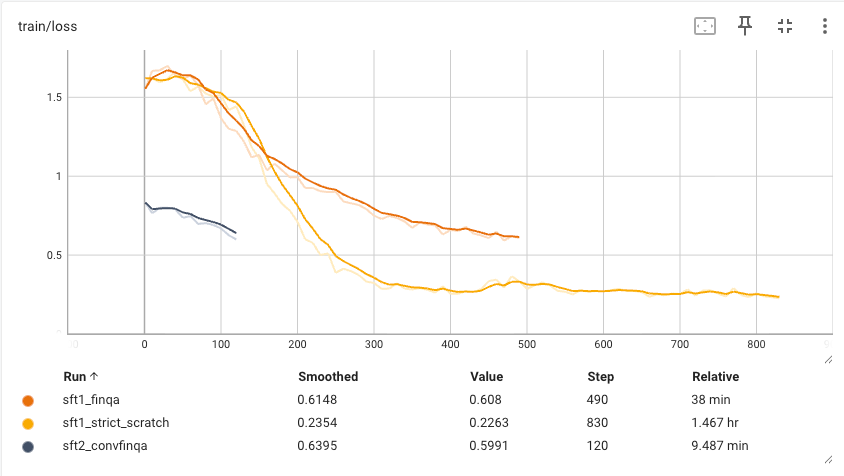

混合训练更容易优化，分阶段训练更容易解释。

拆分FinQA和ConvFinQA：先学硬核金融数值推理，再学对话场景中的 follow-up reasoning。

在当前配置下，混合 FinQA 与 ConvFinQA 的 SFT 训练曲线明显优于只使用 FinQA：前者 loss 下降更快、最终更低，说明 ConvFinQA 没有引入明显噪声，反而可能通过提供更平滑的金融对话推理分布，帮助模型更好地学习金融数值推理任务。但这一结果目前只说明训练可优化性更强，是否真正提升核心推理能力，还需要结合 FinQA/ConvFinQA 的独立验证集进一步评估。

| 曲线                         | 含义                | 训练数据                              |
| -------------------------- | ----------------- | --------------------------------- |
| **sft1_finqa（橙）**          | 第一阶段单独 FinQA      | **只学 FinQA**                      |
| **sft1_strict_scratch（黄）** | 之前的混合训练 baseline  | **FinQA + ConvFinQA 一起学**         |
| **sft2_convfinqa（蓝灰）**     | 第二阶段接着训 ConvFinQA | **在 sft1_finqa 基础上继续学 ConvFinQA** |

从训练曲线看，直接混合 FinQA 与 ConvFinQA 进行 SFT 时，loss 下降更快且最终更低，说明混合数据分布在优化层面更平滑、更易于拟合；而将训练拆分为“FinQA 先学硬数值推理，再用 ConvFinQA 适配对话场景”的两阶段流程，虽然在训练 loss 上未必更优，但更符合任务能力分解逻辑，有利于将模型能力从“单轮金融推理”逐步迁移到“多轮金融对话推理”。因此，混合训练更适合作为高效 baseline，而分阶段训练更适合作为具备明确能力分工的 reasoning model 训练方案。

## 对比实验：将sft1和sft2的数据集进行合并训练

`/root/autodl-tmp/data/financial_reasoning/clean/sft_dir_strict`目录下是
 - `autodl-tmp/data/financial_reasoning/clean/sft_dir_strict/train_sft1_clean_strict.jsonl`
 - `autodl-tmp/data/financial_reasoning/clean/sft_dir_strict/train_sft2_clean_strict.jsonl`

注意训练的时候同一个数据集不要聚集在一起 需要打乱（`supervised_pretrainning`）

In [ ]:
!python supervised_finetuning.py --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning/clean/sft_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 100 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/sft_finqa \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 \
    --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft_lora \
    --template_name qwen

对于金融对话数值推理任务，联合训练（joint training）比简单的分阶段训练更有效。

In [10]:
SFT_OUT = "/root/autodl-tmp/outputs/financial_reasoning/sft_lora"
SFT_MERGED_OUT = "/root/autodl-tmp/outputs/financial_reasoning/sft_merged"

## 8. 轻量 DPO（可选）

轻量 DPO 目标：
- 优化表达质量
- 保持结构完整
- 减少废话
- 不让偏好训练覆盖主干 reasoning 能力


In [23]:
with DPO_MIXED_FILE.open('w', encoding='utf-8') as wf:
    all_specs = SFT1_DATA_SPECS + SFT2_DATA_SPECS
    total_source_target = sum(spec['target_rows'] for spec in all_specs if spec['target_rows'] > 0)
    for spec in all_specs:
        path = DPO_DIR / f"{spec['name']}_dpo.jsonl"
        if total_source_target > 0:
            proportional_target = int(round(DPO_TOTAL_BUDGET * spec['target_rows'] / total_source_target))
        else:
            proportional_target = 0
        dpo_target = min(MAX_DPO_PER_DATASET, spec.get('max_rows') or 10**9, proportional_target)
        sampled = sample_jsonl_records(path, dpo_target, seed=RANDOM_SEED)
        for line in sampled:
            wf.write(line if line.endswith('\n') else line + '\n')

(DPO_TRAIN_DIR / DPO_MIXED_FILE.name).write_text(
    DPO_MIXED_FILE.read_text(encoding='utf-8'),
    encoding='utf-8',
)


13670054

In [14]:
merge_sft_cmd = [
    'python', 'merge_peft_adapter.py',
    '--base_model', BASE_MODEL,
    '--tokenizer_path', BASE_MODEL,
    '--lora_model', str(SFT_OUT),
    '--output_dir', str(SFT_MERGED_OUT),
]
print(' '.join(merge_sft_cmd))
# subprocess.run(merge_sft_cmd, check=True)


python merge_peft_adapter.py --base_model /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --lora_model /root/autodl-tmp/outputs/financial_reasoning/sft_lora --output_dir /root/autodl-tmp/outputs/financial_reasoning/sft_merged


### 8.1 DPO 质量统计展示（训练前）

在执行 `dpo_training.py` 前，先检查 DPO 数据质量：
- 规模与去重
- 结构锚点覆盖（如 `最终答案：/推理程序：`）
- `source_dataset` 分布
- 抽样查看 `chosen/rejected`


In [26]:
from pathlib import Path
import json
import pandas as pd

def _read_jsonl(path: Path):
    rows = []
    bad_lines = []
    with path.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                bad_lines.append((i, line[:120]))

    # fallback: some files were accidentally written with literal "\n" instead of real newline
    if not rows and bad_lines:
        raw = path.read_text(encoding='utf-8')
        if '\\n' in raw and chr(10) not in raw:
            for i, part in enumerate(raw.split('\\n'), start=1):
                part = part.strip()
                if not part:
                    continue
                try:
                    rows.append(json.loads(part))
                except json.JSONDecodeError:
                    bad_lines.append((f'fallback:{i}', part[:120]))

    if bad_lines:
        print(f'[WARN] bad json lines: {len(bad_lines)} (show up to 5)')
        for x in bad_lines[:5]:
            print('  ', x)

    return rows

rows = _read_jsonl(DPO_MIXED_FILE)
if not rows:
    raise ValueError(f'No DPO rows found: {DPO_MIXED_FILE}')

anchors = ['最终答案：', '推理程序：', '结论：', '推理：', '解释：']

def _has_anchor(text: str) -> bool:
    return any(a in (text or '') for a in anchors)

triplets = [
    (r.get('question', ''), r.get('response_chosen', ''), r.get('response_rejected', ''))
    for r in rows
]
unique_triplets = len(set(triplets))

quality_summary = pd.DataFrame([
    {'metric': 'total_rows', 'value': len(rows)},
    {'metric': 'unique_triplets', 'value': unique_triplets},
    {'metric': 'duplicate_triplets', 'value': len(rows) - unique_triplets},
    {'metric': 'empty_question_rows', 'value': sum(1 for r in rows if not str(r.get('question', '')).strip())},
    {'metric': 'empty_chosen_rows', 'value': sum(1 for r in rows if not str(r.get('response_chosen', '')).strip())},
    {'metric': 'empty_rejected_rows', 'value': sum(1 for r in rows if not str(r.get('response_rejected', '')).strip())},
    {'metric': 'chosen_anchor_covered_rows', 'value': sum(1 for r in rows if _has_anchor(r.get('response_chosen', '')))},
    {'metric': 'rejected_anchor_covered_rows', 'value': sum(1 for r in rows if _has_anchor(r.get('response_rejected', '')))},
])

length_df = pd.DataFrame({
    'question_chars': [len(str(r.get('question', ''))) for r in rows],
    'chosen_chars': [len(str(r.get('response_chosen', ''))) for r in rows],
    'rejected_chars': [len(str(r.get('response_rejected', ''))) for r in rows],
}).describe().T[['count', 'mean', '50%', 'max']].reset_index().rename(columns={'index': 'field'})

source_dist_df = (
    pd.DataFrame({'source_dataset': [r.get('source_dataset', '') for r in rows]})
    .value_counts()
    .reset_index(name='rows')
)

preview_rows = []
for r in rows[:8]:
    preview_rows.append({
        'source_dataset': r.get('source_dataset', ''),
        'record_id': r.get('record_id', ''),
        'question_preview': str(r.get('question', ''))[:120],
        'chosen_preview': str(r.get('response_chosen', ''))[:120],
        'rejected_preview': str(r.get('response_rejected', ''))[:120],
    })
preview_df = pd.DataFrame(preview_rows)

print('[DPO quality summary]')
display(quality_summary)
print('\n[Length statistics]')
display(length_df)
print('\n[Source dataset distribution]')
display(source_dist_df)
print('\n[DPO sample preview]')
display(preview_df)


[WARN] bad json lines: 3879 (show up to 5)
   (2, '\\n{"system": "", "history": [], "question": "你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\\n\\n材料（表格前文本）：\\n- abiomed , inc ')
   (3, '\\n{"system": "", "history": [], "question": "你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\\n\\n材料（表格前文本）：\\n- american tower')
   (4, '\\n{"system": "", "history": [], "question": "你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\\n\\n材料（表格前文本）：\\n- notes to conso')
   (5, '\\n{"system": "", "history": [], "question": "你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\\n\\n材料（表格前文本）：\\n- consist of fir')
   (6, '\\n{"system": "", "history": [], "question": "你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\\n\\n材料（表格前文本）：\\n- contractual ca')
[DPO quality summary]


,metric,value
0,total_rows,1
1,unique_triplets,1
2,duplicate_triplets,0
3,empty_question_rows,0
4,empty_chosen_rows,0
5,empty_rejected_rows,0
6,chosen_anchor_covered_rows,1
7,rejected_anchor_covered_rows,1



[Length statistics]


,field,count,mean,50%,max
0,question_chars,1.0,1379.0,1379.0,1379.0
1,chosen_chars,1.0,200.0,200.0,200.0
2,rejected_chars,1.0,175.0,175.0,175.0



[Source dataset distribution]


,source_dataset,rows
0,FinQA,1



[DPO sample preview]


,source_dataset,record_id,question_preview,chosen_preview,rejected_preview
0,FinQA,ADI/2009/page_49.pdf-1,你是一名金融表文混合推理助手。请结合文本、表格和问题，给出可执行的推理程序与最终答案。\n\...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...,问题分析：需要从财报文本和表格中定位相关指标，并依据程序完成数值计算。\n关键证据：\n- ...


In [ ]:
dpo_cmd = [
    'python', 'dpo_training.py',
    '--model_name_or_path', str(SFT_MERGED_OUT),
    '--tokenizer_name_or_path', BASE_MODEL,
    '--template_name', TEMPLATE_NAME,
    '--train_file_dir', str(DPO_TRAIN_DIR),
    '--validation_split_percentage', '1',
    '--do_train',
    '--use_peft', 'True',
    '--per_device_train_batch_size', '1',
    '--gradient_accumulation_steps', '16',
    '--gradient_checkpointing', 'True',
    '--learning_rate', '5e-7',
    '--max_steps', '200',
    '--max_source_length', '1024',
    '--max_target_length', '512',
    '--logging_steps', '10',
    '--save_steps', '200',
    '--target_modules', 'all',
    '--lora_rank', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--torch_dtype', 'float16',
    '--device_map', 'auto',
    '--output_dir', str(DPO_OUT),
]
print(' '.join(dpo_cmd))
# subprocess.run(dpo_cmd, check=True)


python dpo_training.py --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft2_merged --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --template_name qwen --train_file_dir /root/autodl-tmp/data/financial_reasoning/dpo_pairs/train_dir --validation_split_percentage 1 --do_train --use_peft True --per_device_train_batch_size 1 --gradient_accumulation_steps 16 --gradient_checkpointing True --learning_rate 5e-7 --max_steps 200 --max_source_length 1024 --max_target_length 512 --logging_steps 10 --save_steps 200 --target_modules all --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 --torch_dtype float16 --device_map auto --output_dir /root/autodl-tmp/outputs/financial_reasoning/dpo_lora


In [ ]:
!python dpo_training.py --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft_merged \
--tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
--template_name qwen \
--train_file_dir /root/autodl-tmp/data/financial_reasoning/dpo_pairs/train_dir \
--do_train --use_peft True \
--per_device_train_batch_size 1 --gradient_accumulation_steps 16 --gradient_checkpointing True \
--learning_rate 5e-7 --max_steps 200 --max_source_length 1024 --max_target_length 512 \
--logging_steps 10 --save_steps 200 \
--logging_dir /root/autodl-tmp/outputs/financial_reasoning/tensorboard/dpo \
--target_modules q_proj,k_proj,v_proj,o_proj\
--lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
--torch_dtype bfloat16 --device_map auto \
--output_dir /root/autodl-tmp/outputs/financial_reasoning/dpo_lora

## 9. GRPO reward 设计（推荐）

针对金融 reasoning，推荐 3 类 reward：
1. **格式奖励**：是否满足结构化输出格式
2. **程序一致性奖励**：是否包含与 gold program 一致的关键操作
3. **答案正确性奖励**：最终答案是否与 gold answer 一致 / 数值接近

这里给出 reward 设计原型，后续可以把它接到 `grpo_training.py`。


In [ ]:
import re

SECTION_PATTERNS = {
    'analysis': r'问题分析：',
    'program': r'推理程序：',
    'answer': r'最终答案：',
}


def reasoning_format_reward(text: str) -> float:
    score = 0.0
    for pattern in SECTION_PATTERNS.values():
        if re.search(pattern, text):
            score += 1.0
    return score / len(SECTION_PATTERNS)


def extract_final_answer(text: str) -> str:
    m = re.search(r'最终答案：\s*(.+)', text)
    return m.group(1).strip() if m else text.strip()


def normalize_number(text: str):
    m = re.search(r'-?\d+(?:,\d{3})*(?:\.\d+)?', text.replace(',', ''))
    return float(m.group(0)) if m else None


def answer_correctness_reward(pred: str, gold: str, tol: float = 1e-4) -> float:
    pred_num = normalize_number(extract_final_answer(pred))
    gold_num = normalize_number(gold)
    if pred_num is not None and gold_num is not None:
        return 1.0 if abs(pred_num - gold_num) <= tol else 0.0
    return 1.0 if extract_final_answer(pred).strip() == gold.strip() else 0.0


def program_consistency_reward(pred: str, gold_program: str) -> float:
    if not gold_program:
        return 0.0
    pred_program = ''
    m = re.search(r'推理程序：\s*(.+)', pred)
    if m:
        pred_program = m.group(1).strip()
    gold_ops = [op for op in ['add', 'subtract', 'multiply', 'divide', 'greater', 'table_max', 'table_min'] if op in gold_program]
    if not gold_ops:
        return 0.0
    hit = sum(1 for op in gold_ops if op in pred_program)
    return hit / len(gold_ops)

print('reward design ready')


## 10. benchmark 评估（当前主测 FinQA + ConvFinQA）

在 `SFT-2` 训练并 merge 完成后，默认先评估三组模型在核心数值推理上的表现：
- `base`：基座模型
- `sft1`：`SFT1` merge 后模型
- `sft2`：`SFT1 + SFT2` merge 后模型

当前默认 benchmark：
- `ConvFinQA`（优先 `test_turn.json`，若不存在自动回退 `dev_turn.json`）
- `FinQA test`

说明：
- `CFLUE` 暂不评测
- `fingpt-fineval` 通过开关控制，默认关闭


In [ ]:
# 当前阶段主测 FinQA + ConvFinQA，CFLUE 暂不纳入默认评测流程


In [11]:
BENCHMARK_OUTPUT_DIR = OUTPUT_ROOT / "benchmarks" / "sft2_compare_core_reasoning"
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONVFINQA_CANDIDATES = [
    RAW_CACHE_DIR / "convfinqa_turn" / "test_turn.json",
    RAW_CACHE_DIR / "convfinqa_turn" / "dev_turn.json",
]
CONVFINQA_EVAL_FILE = next((p for p in CONVFINQA_CANDIDATES if p.exists()), CONVFINQA_CANDIDATES[0])
CONVFINQA_EVAL_SPLIT = "test_turn" if CONVFINQA_EVAL_FILE.name == "test_turn.json" else "dev_turn"

FINQA_TEST_FILE = RAW_CACHE_DIR / "finqa" / "test.json"

RUN_FINEVAL = False
FINEVAL_TEST_LOCAL_FILE = ""

# 轻量评估开关：True=小样本快速回归，False=全量评估
LIGHT_EVAL = True
LIGHT_EVAL_MAX_NEW_TOKENS = 128
FULL_EVAL_MAX_NEW_TOKENS = 256

LIGHT_EVAL_MAX_SAMPLES = {
    "convfinqa": 48,
    "finqa": 48,
    "fineval": 24,
}

FULL_EVAL_MAX_SAMPLES = {
    "convfinqa": 0,
    "finqa": 0,
    "fineval": 0,
}

EVAL_MAX_SAMPLES = LIGHT_EVAL_MAX_SAMPLES if LIGHT_EVAL else FULL_EVAL_MAX_SAMPLES
EVAL_MAX_NEW_TOKENS = LIGHT_EVAL_MAX_NEW_TOKENS if LIGHT_EVAL else FULL_EVAL_MAX_NEW_TOKENS

print("BENCHMARK_OUTPUT_DIR:", BENCHMARK_OUTPUT_DIR)
print("LIGHT_EVAL:", LIGHT_EVAL)
print("EVAL_MAX_SAMPLES:", EVAL_MAX_SAMPLES)
print("EVAL_MAX_NEW_TOKENS:", EVAL_MAX_NEW_TOKENS)
print("CONVFINQA_EVAL_FILE:", CONVFINQA_EVAL_FILE, CONVFINQA_EVAL_FILE.exists(), "split=", CONVFINQA_EVAL_SPLIT)
print("FINQA_TEST_FILE:", FINQA_TEST_FILE, FINQA_TEST_FILE.exists())
print("RUN_FINEVAL:", RUN_FINEVAL)


BENCHMARK_OUTPUT_DIR: /root/autodl-tmp/outputs/financial_reasoning/benchmarks/sft2_compare_core_reasoning
LIGHT_EVAL: True
EVAL_MAX_SAMPLES: {'convfinqa': 48, 'finqa': 48, 'fineval': 24}
EVAL_MAX_NEW_TOKENS: 128
CONVFINQA_EVAL_FILE: /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/dev_turn.json True split= dev_turn
FINQA_TEST_FILE: /root/autodl-tmp/data/financial_reasoning/raw/finqa/test.json True
RUN_FINEVAL: False


In [12]:
import subprocess

eval_cmd = [
    "python", "evaluate_financial_benchmarks.py",
    "--tokenizer_path", BASE_MODEL,
    "--model_entry", f"base={BASE_MODEL}",
    "--model_entry", f"sft1={SFT1_MERGED_OUT}",
    "--model_entry", f"sft2={SFT2_MERGED_OUT}",
    "--max_new_tokens", str(EVAL_MAX_NEW_TOKENS),
    "--convfinqa_test_file", str(CONVFINQA_EVAL_FILE),
    "--convfinqa_max_samples", str(EVAL_MAX_SAMPLES["convfinqa"]),
    "--finqa_test_file", str(FINQA_TEST_FILE),
    "--finqa_max_samples", str(EVAL_MAX_SAMPLES["finqa"]),
    "--output_dir", str(BENCHMARK_OUTPUT_DIR),
]

if RUN_FINEVAL:
    eval_cmd.extend([
        "--fineval_dataset_name", "FinGPT/fingpt-fineval",
        "--fineval_split", "test",
        "--fineval_max_samples", str(EVAL_MAX_SAMPLES["fineval"]),
    ])
    if FINEVAL_TEST_LOCAL_FILE:
        eval_cmd.extend(["--fineval_local_file", FINEVAL_TEST_LOCAL_FILE])

if not CONVFINQA_EVAL_FILE.exists():
    raise FileNotFoundError(
        "Missing ConvFinQA eval file: expected one of test_turn.json or dev_turn.json under raw/convfinqa_turn"
    )
if not FINQA_TEST_FILE.exists():
    raise FileNotFoundError(f"Missing FinQA test file: {FINQA_TEST_FILE}")

print(f"[info] ConvFinQA split used: {CONVFINQA_EVAL_SPLIT}")
print(" ".join(eval_cmd))
subprocess.run(eval_cmd, check=True)


[info] ConvFinQA split used: dev_turn
python evaluate_financial_benchmarks.py --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --model_entry base=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --model_entry sft1=/root/autodl-tmp/outputs/financial_reasoning/sft1_merged --model_entry sft2=/root/autodl-tmp/outputs/financial_reasoning/sft2_merged --max_new_tokens 128 --convfinqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/dev_turn.json --convfinqa_max_samples 48 --finqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/test.json --finqa_max_samples 48 --output_dir /root/autodl-tmp/outputs/financial_reasoning/benchmarks/sft2_compare_core_reasoning


[eval] model=base path=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct adapter=none


`torch_dtype` is deprecated! Use `dtype` instead!
Evaluating base: 100%|██████████| 361/361 [17:25<00:00,  2.90s/it]


[eval] model=sft1 path=/root/autodl-tmp/outputs/financial_reasoning/sft1_merged adapter=none


Loading weights: 100%|██████████| 339/339 [00:06<00:00, 49.64it/s]
Some parameters are on the meta device because they were offloaded to the cpu.
Evaluating sft1:   5%|▍         | 17/361 [35:39<12:01:38, 125.87s/it]
Traceback (most recent call last):
  File "/root/MedicalGPT/evaluate_financial_benchmarks.py", line 684, in <module>
    main()
  File "/root/MedicalGPT/evaluate_financial_benchmarks.py", line 651, in main
    prediction = generate_response(model, tokenizer, example.prompt, args)
  File "/root/miniconda3/envs/llm/lib/python3.10/site-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
  File "/root/MedicalGPT/evaluate_financial_benchmarks.py", line 434, in generate_response
    outputs = model.generate(
  File "/root/miniconda3/envs/llm/lib/python3.10/site-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
  File "/root/miniconda3/envs/llm/lib/python3.10/site-packages/transform

KeyboardInterrupt: 